## Imports

In [1]:
import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
from itertools import islice
from operator import itemgetter

import networkx as nx
import numpy as np
from astropy import units as u
from astropy.coordinates import ICRS, SkyCoord
from astropy_healpix import HEALPix
from docplex.mp.progress import FunctionalSolutionListener
from IPython.display import clear_output, display
from ligo.skymap import plot
from m4opt import fov
from m4opt.fov._core import circle_to_polygon
from m4opt.milp import Model
from m4opt.skygrid import _geodesic
from m4opt.utils.console import progress, status
from m4opt.utils.optimization import partition_graph, partition_graph_color
from matplotlib import cm, colors
from matplotlib import pyplot as plt
from regions import PointSkyRegion, Regions

## Basic parameters

* `geodesic_args`: Parameters of the geodesic sky grid tiling.
* `k`: Number of sky blocks.

In [3]:
# Valutes for actual survey
geodesic_args = (21, 4, "icosahedron")
k = 271

# Values for fast test of algorithm
# geodesic_args = (4, 4, "icosahedron")
# k = 20

## Problem setup

Generate sky grid.

In [4]:
coords = _geodesic.for_subdivision(*geodesic_args)

Generate costs: proportional to the number of exposures required for each field.

In [17]:
# Exposure times and candeces taken from UVEX Design Reference Mission
# Version 1.0, 11/20/2025
base_limmag = np.asarray([25.25, 24.25])  # All-sky (NUV, MUV) survey depth
allsky_visits = 3
allsky_limmag = base_limmag + 1.25 * np.log10(
    allsky_visits
)  # 3 exposures per year, cadence of 1/(4 months)

lmlz_wide_limmag = np.asarray([25.75, 25.75])
lmlz_deep_limmag = np.asarray([27.0, 27.0])
mc_limmag = np.asarray([24.5, 24.5])  # Magellanic clouds survey depth
mc_limmag += 1.25 * np.log10(52 * 2)  # 2/week cadence

lmlz_wide_regions = Regions.read("survey-footprints/lmlz-wide.ds9")
lmlz_deep_regions = Regions.read("survey-footprints/lmlz-deep.ds9")
mc_regions = Regions.read("survey-footprints/magellanic-clouds.ds9")

survey_regions = [lmlz_wide_regions, lmlz_deep_regions, mc_regions]
region_costs = 10 ** (
    (np.asarray([lmlz_wide_limmag, lmlz_deep_limmag, mc_limmag]) - allsky_limmag).max(
        axis=-1
    )
    / 1.25
)

hpx = HEALPix(512, frame=ICRS())
overlap_fraction = 0.1
(inscribed_circle,) = Regions.read("fov-inscribed-circle.ds9")
hpx_fields = [set(_) for _ in fov.footprint_healpix(hpx, inscribed_circle, coords)]
costs = np.full(len(coords), 1)
for region_cost, regions in sorted(zip(region_costs, survey_regions)):
    hpx_regions = set(fov.footprint_healpix(hpx, regions, SkyCoord("0d 0d")))
    for i, hpx_field in enumerate(hpx_fields):
        if len(hpx_regions.intersection(hpx_field)) >= overlap_fraction * len(
            hpx_field
        ):
            costs[i] = region_cost

Plot fields and their weights.

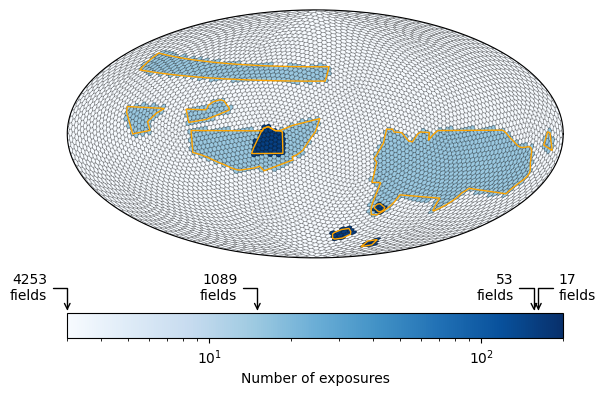

In [18]:
fig = plt.figure()
shift = 4 * u.hourangle
ax = plt.axes(
    projection="astro aitoff", center=SkyCoord(12 * u.hourangle - shift, 0 * u.deg)
)
for key in ["ra", "dec"]:
    ax.coords[key].set_ticklabel_visible(False)
    ax.coords[key].set_ticks_visible(False)
transform = ax.get_transform("world")
scalar_mappable = cm.ScalarMappable(norm=colors.LogNorm(vmin=3, vmax=200), cmap="Blues")
for cost, region in sorted(
    zip(costs * allsky_visits, fov.footprint(inscribed_circle, coords)),
    key=itemgetter(0),
):
    vertices = circle_to_polygon(region, 16).vertices
    for cut_vertices in plot.cut_prime_meridian(
        np.column_stack(((vertices.ra + shift).to_value(u.rad), vertices.dec.rad))
    ):
        cut_vertices[:, 0] -= shift.to_value(u.rad)
        ax.add_patch(
            plt.Polygon(
                np.rad2deg(cut_vertices),
                ec="none",
                lw=0,
                fc=scalar_mappable.to_rgba(cost),
                closed=True,
                fill=True,
                transform=transform,
            )
        )
for region in fov.footprint(inscribed_circle, coords):
    vertices = circle_to_polygon(region, 16).vertices
    for cut_vertices in plot.cut_prime_meridian(
        np.column_stack(((vertices.ra + shift).to_value(u.rad), vertices.dec.rad))
    ):
        cut_vertices[:, 0] -= shift.to_value(u.rad)
        ax.add_patch(
            plt.Polygon(
                np.rad2deg(cut_vertices),
                ec="black",
                lw=0.125,
                fc="none",
                closed=True,
                fill=False,
                transform=transform,
            )
        )
cbar = plt.colorbar(
    scalar_mappable,
    ax=ax,
    orientation="horizontal",
)
cbar.set_label("Number of exposures")

for tick, count in zip(*np.unique(costs, return_counts=True)):
    kwargs = dict(
        xytext=(-20, 10),
        ha="right",
        arrowprops=dict(arrowstyle="->", connectionstyle="angle,angleA=0,angleB=90"),
    )
    if tick == costs.max():
        kwargs["xytext"] = (20, 10)
        kwargs["ha"] = "left"
        kwargs["arrowprops"]["connectionstyle"] = "angle,angleA=0,angleB=90"
    cbar.ax.annotate(
        text=f"{count}\nfields",
        xy=(tick * allsky_visits, 1),
        xycoords=("data", "axes fraction"),
        textcoords="offset pixels",
        va="bottom",
        **kwargs,
    )

for region in [*lmlz_wide_regions, *lmlz_deep_regions, *mc_regions]:
    if isinstance(region, PointSkyRegion):
        pass  # ax.plot_coord(region.center, '+r')
    else:
        ax.add_patch(region.to_pixel(ax.wcs).as_artist(edgecolor="orange", linewidth=1))
fig.savefig("costs.pdf")

Convert to a weighted graph.

In [6]:
# Construct graph from nearest neighbors
distances = coords[:, np.newaxis].separation(coords).to_value(u.deg)
np.fill_diagonal(distances, np.inf)  # no loops
n = 2 * _geodesic.num_edges(*geodesic_args)
i = np.argpartition(distances, n, axis=None)[:n]
adjacency = np.zeros_like(distances, dtype=bool)
adjacency.flat[i] = True
graph = nx.from_numpy_array(adjacency)

# Add costs to graph
for (_, data), cost in zip(graph.nodes(data=True), costs):
    data["cost"] = cost

In [7]:
# Construct edge weights that reward strips in right ascension.
d_lon, d_lat = coords[:, np.newaxis].spherical_offsets_to(coords[np.newaxis, :])
lon_weight = 1
lat_weight = 1000
power = 3
edge_weights = np.ceil(
    (lon_weight * np.abs(d_lon) ** power + lat_weight * np.abs(d_lat) ** power).value
).astype(int)
edge_weights[~adjacency] = 0

for i, j, data in graph.edges(data=True):
    data["ground_based_weight"] = edge_weights[i, j]

/Users/lpsinger/src/uvex-scheduler/.venv/lib/python3.13/site-packages/regions/shapes/polygon.py:180: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Polygon(xy=xy, **mpl_kwargs)


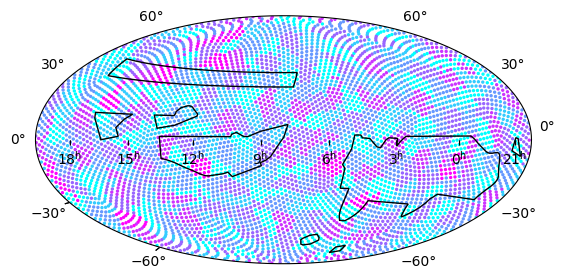

In [97]:
fig = plt.figure()
ax = fig.add_subplot(projection="astro aitoff", center="8h 0d")
ax.scatter_coord(
    coords,
    c=partition_graph_color(graph, partition)[partition],
    s=2,
    cmap="cool",
)
for region in [*lmlz_wide_regions, *mc_regions]:
    ax.add_patch(region.to_pixel(ax.wcs).as_artist(color="black"))

## Partition into sky blocks

We have $N$ fields. Our objective is to partition them into $k$ connected blocks, such that all blocks contain between $n_\mathrm{min} = \left\lfloor\frac{N}{k}\right\rfloor$ and $n_\mathrm{max} = \left\lceil\frac{N}{k}\right\rceil$ fields. Each field has an associated weight which is proportional to the number of exposures required. The weight of each block is the maximum of the weights of all of the fields inside it. We want to minimize the sum of the weights of all of the blocks.

This is a variation of the Balanced Connected Partition (BCP) problem. We use an adaptation of the MILP formulation given in Section 4 of [arXiv:1911.05723](https://arxiv.org/abs/1911.05723). Consider a graph $G$ with vertex set $V(G)$ and edge set $E(G)$. Let $w : V(G) \rightarrow \mathbb{R}$ be a function that assigns weights to each vertex of $G$. Let $w_\mathrm{min} = \min_{v \in V(G)} {w(v)}$, $w_\mathrm{max} = \max_{v \in V(G)} {w(v)}$. Create a digraph $D_G \subset D$ with arc set $A(D)$ as in [arXiv:1911.05723](https://arxiv.org/abs/1911.05723): for each edge in $G$, create two arcs with the same nodes but in both opposite directions. Then add $k$ new vertices from the set $S = \left\{ s_1, \dots, s_k \right\}$. Finally, add an arc from each vertex in $S$ to each vertex in $G$, the subgraph containing only those arcs forming graph $D_S \subset D$. Denote the set of arcs going into node $v$ by $\delta^-(v)$ and the set of arcs going out of the node by $\delta^+(v)$.

Bounded integer variables representing the flows between nodes $V(G)$:

$$
    f_a \in \mathbb{Z} \mid 0 \leq f_a \leq n_\mathrm{max} - 1 \quad \forall a \in A(D_G)
$$

Semiinteger variables representing the flows between $S$ and $V(G)$:

$$
    f_a \in \mathbb{Z} \mid f_a = 0 \lor n_\mathrm{min} \leq f_a \leq n_\mathrm{max} \quad \forall a \in A(D_G)
$$

Bounded real variables representing the cost of the flow emanating from each node:

$$
    x_v \in \mathbb{R} \mid w(v) \leq x_v \leq w_\mathrm{max} \quad \forall v \in V(D)
$$

Each node consumes exactly 1 unit of flow.

$$
    \sum_{a \in \delta^-(v)} f_a - \sum_{a \in \delta^+(v)} f_a = 1 \quad \forall V(D) \setminus S
$$

SOS1 constraints enforcing that exactly one arc from each node $s$ in $S$ has nonzero flow:

$$
    \mathrm{SOS1}(\left\{f_a | a \in \delta^+(s)\right\}) \quad \forall s \in S
$$

SOS1 constraints enforcing that, for each node $v$ in $V(G)$, exactly one inbound arc has nonzero flow:

$$
    \mathrm{SOS1}(\left\{f_a | a \in \delta^-(s)\right\}) \quad \forall v \in V(D) \setminus S
$$

If-then constraints enforcing that, for each arc in the graph, if there is nonzero flow across the arc, then the cost of the source node is greater than or equal to the cost of the sink node.

$$
    f_a \geq 1 \Rightarrow x_u \geq x_v \quad \forall a = (u, v) \in A(D)
$$

Minimize the quantity

$$
    \sum_{s \in S} x_s
$$

In [ ]:
nmin = int(np.floor(graph.number_of_nodes() / k))
nmax = int(np.ceil(graph.number_of_nodes() / k))
min_cost = min(data["cost"] for _, data in graph.nodes(data=True))
max_cost = max(data["cost"] for _, data in graph.nodes(data=True))

with progress():
    with status("augmenting graph"):
        # Construct digraph with edges only from nodes only in the direction of nondecreasing cost
        digraph = graph.to_directed()

        # Add nodes for flow sources for each subgraph
        unique = object()
        flow_source_nodes = [(unique, i) for i in range(k)]

        # Add edges from each flow source to each node
        digraph.add_nodes_from(flow_source_nodes, cost=min_cost)
        digraph.add_weighted_edges_from(
            (
                (node1, node2, data["cost"])
                for node1 in flow_source_nodes
                for node2, data in graph.nodes(data=True)
            ),
            weight="cost",
        )

    with Model(timelimit=2 * u.min) as m:
        with status("adding flow variables"):
            for node1, node2, data in digraph.edges(data=True):
                if node1 in flow_source_nodes:
                    data["flow"] = m.integer_var(lb=0, ub=nmax)
                else:
                    data["flow"] = m.integer_var(lb=0, ub=nmax - 1)
                data["flow_on"] = m.binary_var()

        with status("adding cost variables"):
            for _, data in digraph.nodes(data=True):
                data["cost"] = m.continuous_var(lb=data["cost"], ub=max_cost)

        with status("adding constraint: each node consumes exactly 1 unit of flow"):
            m.add_constraints_(
                m.sum_vars_all_different(
                    data["flow"] for _, _, data in digraph.in_edges(node, data=True)
                )
                - m.sum_vars_all_different(
                    data["flow"] for _, _, data in digraph.out_edges(node, data=True)
                )
                == 1
                for node in graph.nodes
            )

        with status("adding constraint: uniqueness of out flows"):
            # Each flow source node sends flow to exactly one other node
            for node in flow_source_nodes:
                m.add_sos1(
                    [
                        data["flow_on"]
                        for _, _, data in digraph.out_edges(node, data=True)
                    ]
                )

        with status("adding constraint: uniqueness of in flows"):
            # Each node consumes flow from exactly one other node
            for node in graph.nodes:
                m.add_sos1(
                    [
                        data["flow_on"]
                        for _, _, data in digraph.in_edges(node, data=True)
                    ]
                )

        for node1, node2, edge_data in digraph.edges(data=True):
            m.add_constraint_(nmax * edge_data["flow_on"] >= edge_data["flow"])

        with status("adding constraint: costs"):
            node_costs = digraph.nodes(data="cost")
            for node1, node2, edge_data in digraph.edges(data=True):
                m.add_indicator(
                    edge_data["flow_on"], node_costs[node1] >= node_costs[node2]
                )

        # Break some symmetries
        # m.add_constraints_(node_costs[i] >= node_costs[i + 1] for i in range(k - 1))
        # m.add_constraint_(
        #     m.sum_vars_all_different(
        #         [
        #             data["cost"]
        #             for node, data in digraph.nodes(data=True)
        #             if node in flow_source_nodes
        #         ]
        #     )
        #     >= max_cost + min_cost * (k - 1)
        # )

        with status("adding objective"):
            m.minimize(
                m.sum_vars_all_different(
                    [
                        data["cost"]
                        for node, data in digraph.nodes(data=True)
                        if node in flow_source_nodes
                    ]
                )
            )

        def read_solution(solution):
            edges, flows = list(
                zip(
                    *(
                        ((v1, v2), data["flow"])
                        for v1, v2, data in digraph.edges(data=True)
                    )
                )
            )
            flows = np.rint(solution.get_values(flows)).astype(bool)
            out_digraph = digraph.copy()
            out_digraph.remove_edges_from(
                edge for edge, flow in zip(edges, flows) if not flow
            )
            out_digraph.remove_nodes_from(flow_source_nodes)
            out_graph = nx.convert_node_labels_to_integers(
                out_digraph.to_undirected(as_view=True)
            )
            partition = np.empty(out_graph.number_of_nodes(), dtype=np.intp)
            for component, nodes in enumerate(nx.connected_components(out_graph)):
                partition[list(nodes)] = component
            return partition

        def plot_solution(solution):
            partition = read_solution(solution)
            fig = plt.figure()
            ax = fig.add_subplot(projection="astro aitoff", center="8h 0d")
            ax.scatter(
                coords.ra.deg,
                coords.dec.deg,
                c=partition_graph_color(graph, partition)[partition],
                cmap="cool",
                transform=ax.get_transform("world"),
            )
            for region in [*lmlz_wide_regions, *lmlz_deep_regions, *mc_regions]:
                ax.add_patch(region.to_pixel(ax.wcs).as_artist(color="black"))
            clear_output(wait=True)
            display(fig)

        m.add_progress_listener(FunctionalSolutionListener(plot_solution, absdiff=1))

        with status("solving"):
            solution = m.solve()

    with status("reading solution"):
        partition = read_solution(solution)

Checking license ...
License found. [1.06 s]
Version identifier: 22.1.2.0 | 2026-03-02 | af0ce9b93
CPXPARAM_Read_DataCheck                          1
CPXPARAM_Parallel                                -1
CPXPARAM_Emphasis_MIP                            1
CPXPARAM_MIP_Pool_Capacity                       0
CPXPARAM_TimeLimit                               120
CPXPARAM_WorkDir                                 "/var/folders/w5/pgrtm0vs1psb88v7z4fz0lh084mbdz/T"
Legacy callback                                  i
Presolve has eliminated 0 rows and 22 columns...
Presolve time = 7.64 sec. (5375862.35 ticks)

Root node processing (before b&c):
  Real time             =    7.74 sec. (5376055.35 ticks)
Parallel b&c, 16 threads:
  Real time             =    0.00 sec. (0.00 ticks)
  Sync time (average)   =    0.00 sec.
  Wait time (average)   =    0.00 sec.
                          ------------
Total (root+branch&cut) =    7.74 sec. (5376055.35 ticks)


AttributeError: 'NoneType' object has no attribute 'get_values'

Yikes. That's never going to converge. Let's try something else.

In [ ]:
nmin = int(np.floor(graph.number_of_nodes() / k))
nmax = int(np.ceil(graph.number_of_nodes() / k))

# Create digraph with arcs in the direction of nondecreasing node cost
node_costs = graph.nodes(data="cost")
digraph = nx.subgraph_view(
    graph.to_directed(), filter_edge=lambda u, v: node_costs[u] >= node_costs[v]
).copy()

sentinel = object()
flow_source_nodes = [(sentinel, i) for i in range(k)]

with Model(jobs=10) as m:
    flow_source_cost_lb = np.sort(costs)[::-1][::nmax][:k][::-1]
    flow_source_cost_ub = np.sort(costs)[-k:]
    flow_source_costs = m.continuous_vars(
        k, lb=flow_source_cost_lb, ub=flow_source_cost_ub
    )

    digraph.add_edges_from(
        (flow_source_node, node)
        for node, data in graph.nodes(data=True)
        for flow_source_node, lb, ub in zip(
            flow_source_nodes, flow_source_cost_lb, flow_source_cost_ub
        )
        if lb <= data["cost"] <= ub
    )

    for node, _, data in digraph.edges.data():
        if node in flow_source_nodes:
            data["flow"] = m.semiinteger_var(lb=nmin, ub=nmax)
        else:
            data["flow"] = m.integer_var(lb=0, ub=nmax - 1)

    # Eq. (8)
    m.add_constraints_(
        m.sum_vars_all_different(
            data["flow"] for _, _, data in digraph.in_edges(node, data=True)
        )
        - m.sum_vars_all_different(
            data["flow"] for _, _, data in digraph.out_edges(node, data=True)
        )
        == 1
        for node in graph.nodes
    )

    # Eq. (10)
    for node in flow_source_nodes:
        m.add_sos1([data["flow"] for _, _, data in digraph.out_edges(node, data=True)])

    # Eq. (11)
    for node in graph.nodes:
        m.add_sos1([data["flow"] for _, _, data in digraph.in_edges(node, data=True)])

    node_costs = graph.nodes(data="cost")
    for node, flow_source_cost in zip(flow_source_nodes, flow_source_costs):
        for _, out_node, data in digraph.out_edges(node, data=True):
            m.add_if_then(data["flow"] >= 1, flow_source_cost >= node_costs[out_node])
        # m.add_constraint_(
        #     nmax * flow_source_cost >=
        #     m.scal_prod_vars_all_different(
        #         [data["flow"] for _, _, data in digraph.out_edges(node, data=True)],
        #         [node_costs[out_node] for _, out_node in digraph.out_edges(node)],
        #     )
        # )

    m.add_constraints_(
        flow_source_costs[i] <= flow_source_costs[i + 1] for i in range(k - 1)
    )
    m.minimize(m.sum_vars_all_different(flow_source_costs))

    # Eq. (7)
    m.add_constraints_(
        m.sum_vars_all_different(
            data["flow"]
            for _, _, data in digraph.out_edges(flow_source_nodes[i], data=True)
        )
        <= m.sum_vars_all_different(
            data["flow"]
            for _, _, data in digraph.out_edges(flow_source_nodes[i + 1], data=True)
        )
        for i in range(k - 1)
    )

    def read_solution(solution):
        edges, flows = list(
            zip(
                *(((v1, v2), data["flow"]) for v1, v2, data in digraph.edges(data=True))
            )
        )
        flows = np.rint(solution.get_values(flows)).astype(bool)
        out_digraph = digraph.copy()
        out_digraph.remove_edges_from(
            edge for edge, flow in zip(edges, flows) if not flow
        )
        out_digraph.remove_nodes_from(flow_source_nodes)
        out_graph = nx.convert_node_labels_to_integers(
            out_digraph.to_undirected(as_view=True)
        )
        partition = np.empty(out_graph.number_of_nodes(), dtype=np.intp)
        for component, nodes in enumerate(nx.connected_components(out_graph)):
            partition[list(nodes)] = component
        return partition

    def plot_solution(solution):
        partition = read_solution(solution)
        fig = plt.figure()
        ax = fig.add_subplot(projection="astro aitoff", center="8h 0d")
        ax.scatter(
            coords.ra.deg,
            coords.dec.deg,
            c=partition_graph_color(graph, partition)[partition],
            cmap="cool",
            transform=ax.get_transform("world"),
        )
        for region in [*lmlz_wide_regions, *mc_regions]:
            ax.add_patch(region.to_pixel(ax.wcs).as_artist(color="black"))
        clear_output(wait=True)
        display(fig)

    m.add_progress_listener(FunctionalSolutionListener(plot_solution))

    solution = m.solve()

partition = read_solution(solution)
plot_solution(solution);

That was pretty slow too. Let's try to do this by hand.

In [ ]:
# Identify all connected components consisting of nodes with weights > 1,
# then contract each such component to one node.
node_costs = graph.nodes(data="cost")
connected_components = list(
    nx.connected_components(
        nx.subgraph_view(graph, filter_node=lambda node: node_costs[node] > 1)
    )
)
contracted_graph = nx.quotient_graph(
    graph,
    [
        # Partitions for connected components
        *connected_components,
        # Partitions for all remaining nodes, one node to each partition
        *({node} for node in graph.nodes - set.union(*connected_components)),
    ],
)

In [ ]:
# Partition the graph abitrarily into smaller connected subgraphs with balanced numbers of nodes.
# max_nnodes = max(value for _, value in contracted_graph.nodes(data='nnodes'))
# k = graph.number_of_nodes() // max_nnodes
k = 20

initial_contracted_partition = partition_graph(
    contracted_graph, k, vweights="nnodes", contig=True, recursive=True
)
initial_partition = np.full(graph.number_of_nodes(), -1, dtype=np.intp)
for nodes, assignment in zip(contracted_graph.nodes, initial_contracted_partition):
    initial_partition[list(nodes)] = assignment
assert np.all(initial_partition >= 0)

/Users/lpsinger/src/uvex-scheduler/.venv/lib/python3.13/site-packages/regions/shapes/polygon.py:180: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Polygon(xy=xy, **mpl_kwargs)


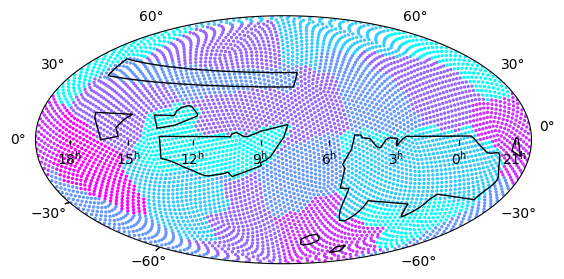

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection="astro aitoff", center="8h 0d")
ax.scatter(
    coords.ra.deg,
    coords.dec.deg,
    c=partition_graph_color(graph, initial_partition)[initial_partition],
    s=2,
    cmap="cool",
    transform=ax.get_transform("world"),
)
for region in [*lmlz_wide_regions, *mc_regions]:
    ax.add_patch(region.to_pixel(ax.wcs).as_artist(color="black"))

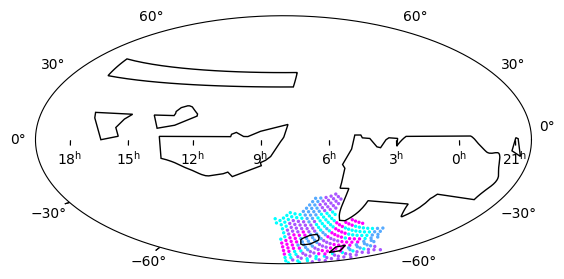

      0     0        cutoff            120.0000      120.0000     3191    0.00%
Elapsed time = 1.04 sec. (2754.76 ticks, tree = 0.01 MB)

Cover cuts applied:  233
Implied bound cuts applied:  3
Flow cuts applied:  542
Mixed integer rounding cuts applied:  48
Flow path cuts applied:  1
Zero-half cuts applied:  157
Multi commodity flow cuts applied:  97
Gomory fractional cuts applied:  65

Root node processing (before b&c):
  Real time             =    1.04 sec. (2755.26 ticks)
Parallel b&c, 10 threads:
  Real time             =    0.00 sec. (0.00 ticks)
  Sync time (average)   =    0.00 sec.
  Wait time (average)   =    0.00 sec.
                          ------------
Total (root+branch&cut) =    1.04 sec. (2755.26 ticks)
Version identifier: 22.1.2.0 | 2026-03-02 | af0ce9b93
CPXPARAM_Read_DataCheck                          1
CPXPARAM_Threads                                 10
CPXPARAM_Parallel                                -1
CPXPARAM_MIP_Pool_Capacity                       0
CPXPARAM_

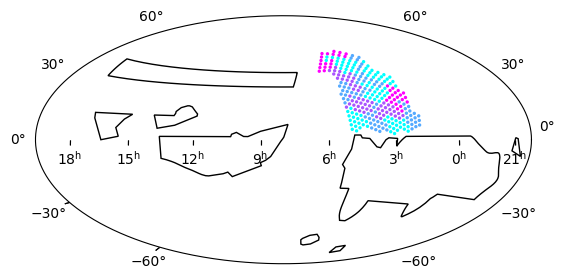

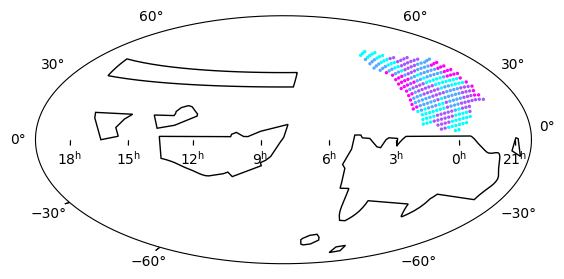

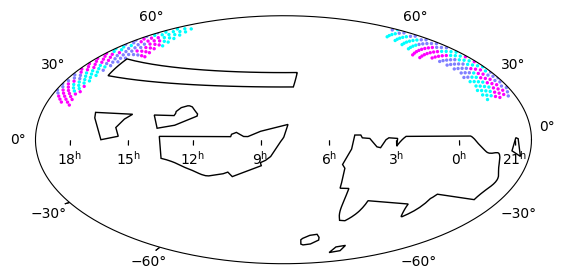

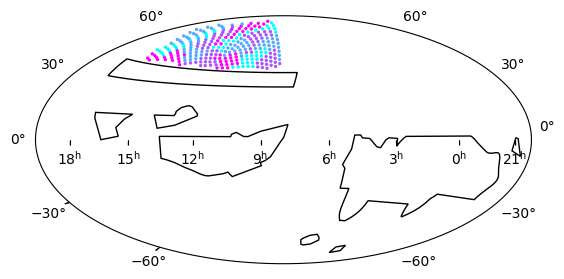

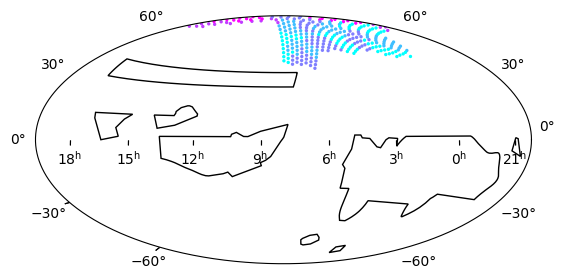

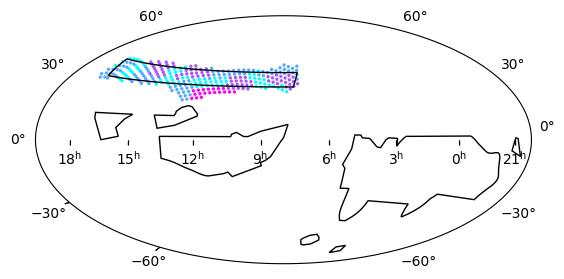

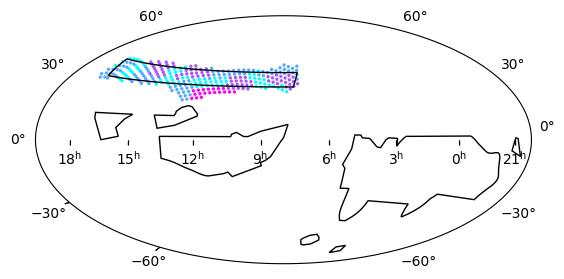

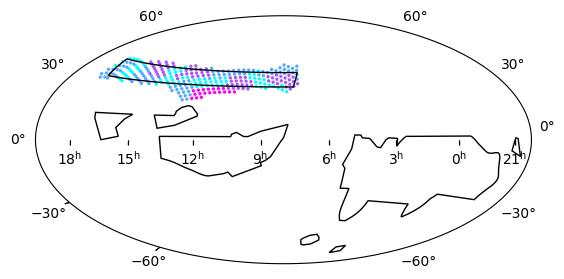

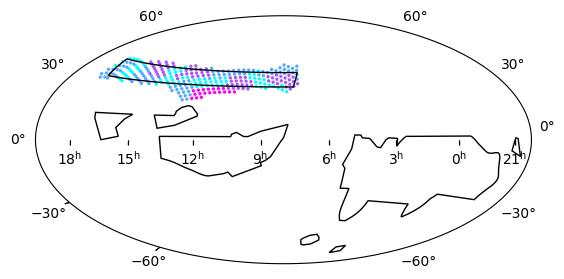

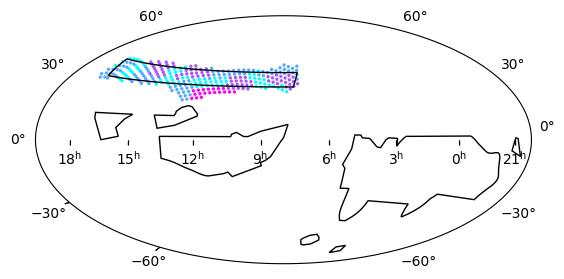

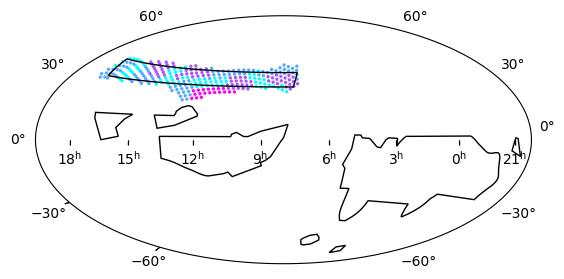

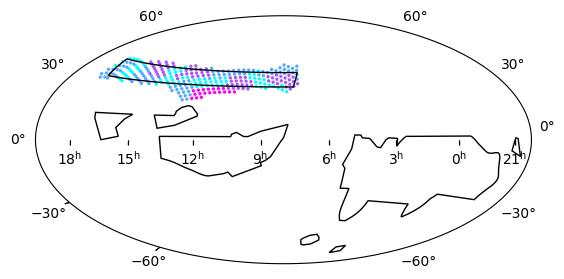

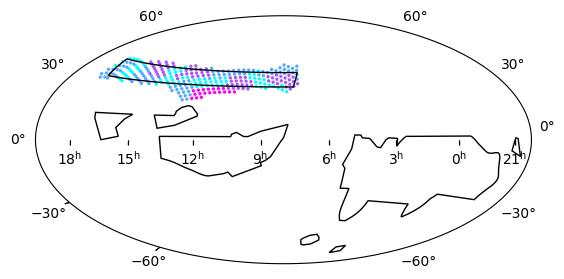

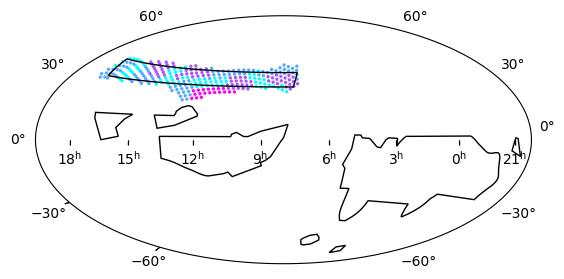

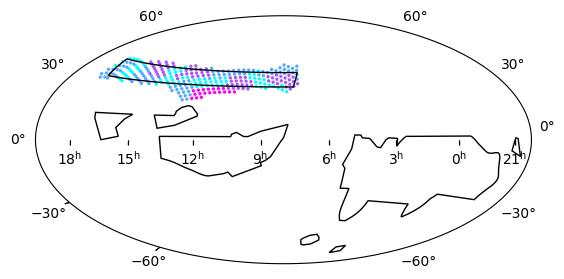

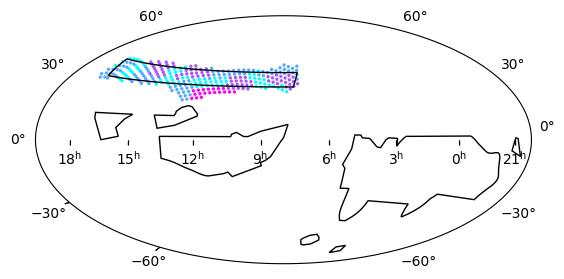

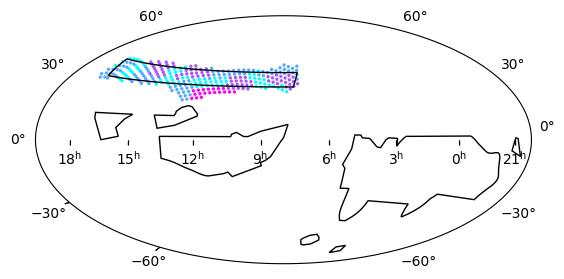

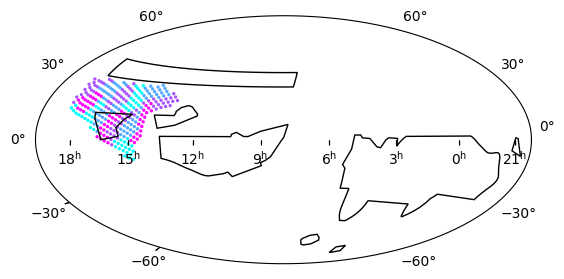

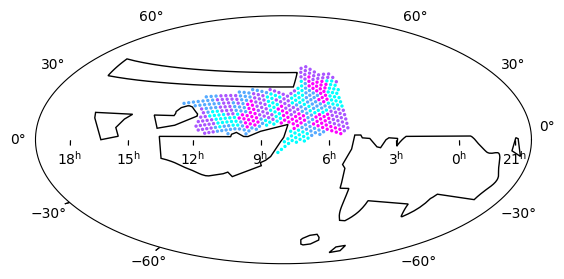

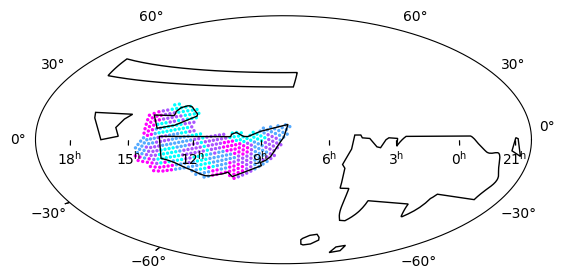

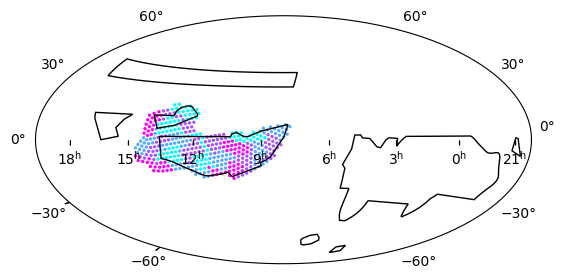

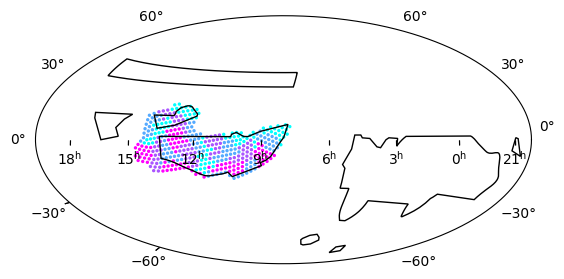

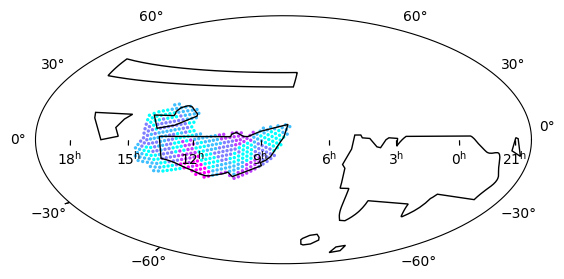

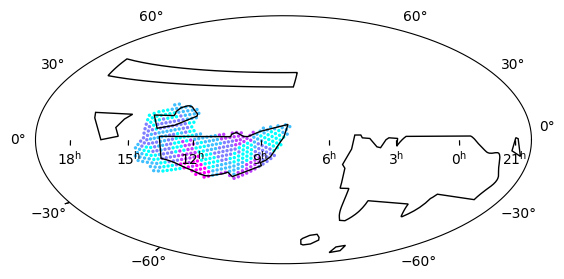

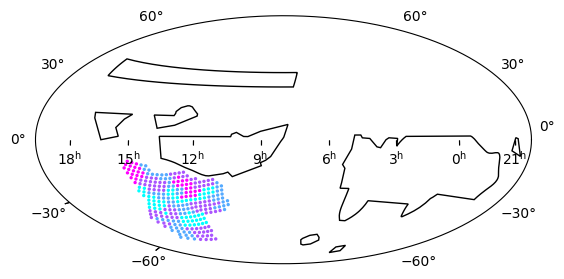

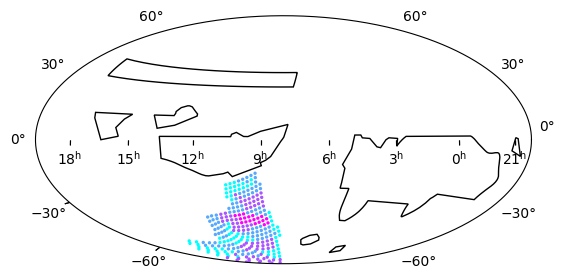

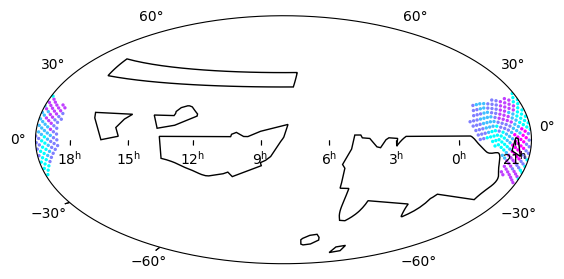

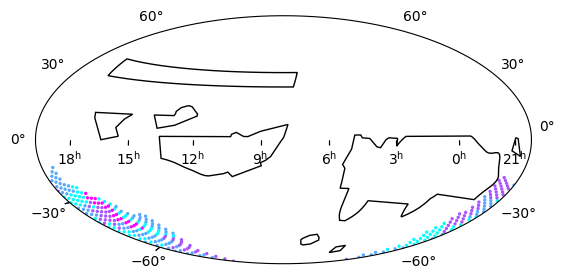

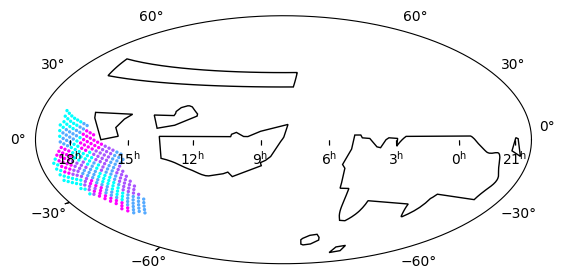

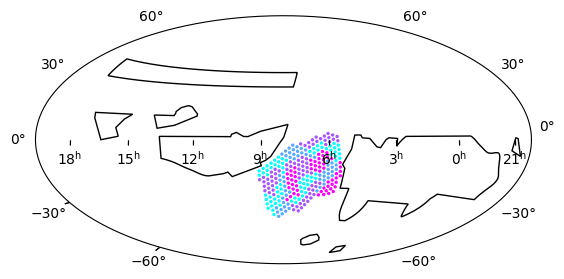

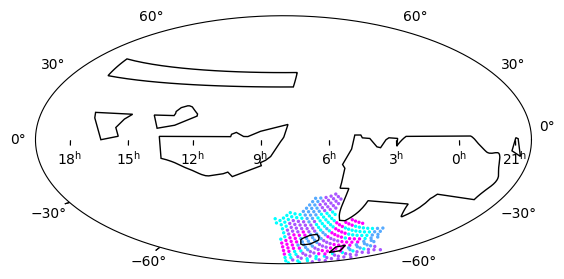

In [75]:
for initial_partition_i in np.unique(initial_partition):
    subgraph = graph.subgraph(
        nodes=np.flatnonzero(initial_partition == initial_partition_i)
    )
    nmax = 20
    nmin = nmax - 1
    k = int(np.ceil(subgraph.number_of_nodes() / nmax))

    # Create digraph with arcs in the direction of nondecreasing node cost
    node_costs = subgraph.nodes(data="cost")
    digraph = nx.subgraph_view(
        subgraph.to_directed(), filter_edge=lambda u, v: node_costs[u] >= node_costs[v]
    ).copy()

    sentinel = object()
    flow_source_nodes = [(sentinel, i) for i in range(k)]
    subgraph_costs = np.asarray([value for _, value in subgraph.nodes(data="cost")])

    with Model(jobs=10) as m:
        flow_source_cost_lb = np.sort(subgraph_costs)[::-1][::nmax][:k][::-1]
        flow_source_cost_ub = np.sort(subgraph_costs)[-k:]
        flow_source_costs = m.continuous_vars(
            k, lb=flow_source_cost_lb, ub=flow_source_cost_ub
        )

        digraph.add_edges_from(
            (flow_source_node, node)
            for node, data in subgraph.nodes(data=True)
            for flow_source_node, lb, ub in zip(
                flow_source_nodes, flow_source_cost_lb, flow_source_cost_ub
            )
            if lb <= data["cost"] <= ub
        )

        for node, _, data in digraph.edges.data():
            if isinstance(node, tuple):
                data["flow"] = m.semiinteger_var(lb=nmin, ub=nmax)
            else:
                data["flow"] = m.integer_var(lb=0, ub=nmax - 1)

        # Eq. (8)
        m.add_constraints_(
            m.sum_vars_all_different(
                data["flow"] for _, _, data in digraph.in_edges(node, data=True)
            )
            - m.sum_vars_all_different(
                data["flow"] for _, _, data in digraph.out_edges(node, data=True)
            )
            == 1
            for node in subgraph.nodes
        )

        # Eq. (10)
        for node in flow_source_nodes:
            m.add_sos1(
                [data["flow"] for _, _, data in digraph.out_edges(node, data=True)]
            )

        # Eq. (11)
        for node in subgraph.nodes:
            m.add_sos1(
                [data["flow"] for _, _, data in digraph.in_edges(node, data=True)]
            )

        node_costs = subgraph.nodes(data="cost")
        for node, flow_source_cost in zip(flow_source_nodes, flow_source_costs):
            for _, out_node, data in digraph.out_edges(node, data=True):
                m.add_if_then(
                    data["flow"] >= 1, flow_source_cost >= node_costs[out_node]
                )
            # m.add_constraint_(
            #     nmax * flow_source_cost >=
            #     m.scal_prod_vars_all_different(
            #         [data["flow"] for _, _, data in digraph.out_edges(node, data=True)],
            #         [node_costs[out_node] for _, out_node in digraph.out_edges(node)],
            #     )
            # )

        m.add_constraints_(
            flow_source_costs[i] <= flow_source_costs[i + 1] for i in range(k - 1)
        )
        m.minimize(m.sum_vars_all_different(flow_source_costs))

        # Eq. (7)
        m.add_constraints_(
            m.sum_vars_all_different(
                data["flow"]
                for _, _, data in digraph.out_edges(flow_source_nodes[i], data=True)
            )
            <= m.sum_vars_all_different(
                data["flow"]
                for _, _, data in digraph.out_edges(flow_source_nodes[i + 1], data=True)
            )
            for i in range(k - 1)
        )

        def read_solution(solution):
            edges, flows = list(
                zip(
                    *(
                        ((v1, v2), data["flow"])
                        for v1, v2, data in digraph.edges(data=True)
                    )
                )
            )
            flows = np.rint(solution.get_values(flows)).astype(bool)
            out_digraph = digraph.copy()
            out_digraph.remove_edges_from(
                edge for edge, flow in zip(edges, flows) if not flow
            )
            out_digraph.remove_nodes_from(flow_source_nodes)
            out_graph = nx.convert_node_labels_to_integers(
                out_digraph.to_undirected(as_view=True)
            )
            partition = np.empty(out_graph.number_of_nodes(), dtype=np.intp)
            for component, nodes in enumerate(nx.connected_components(out_graph)):
                partition[list(nodes)] = component
            return partition

        def plot_solution(solution):
            partition = read_solution(solution)
            fig = plt.figure()
            ax = fig.add_subplot(projection="astro aitoff", center="8h 0d")
            keep_nodes = np.asarray(subgraph.nodes)
            ax.scatter(
                coords[keep_nodes].ra.deg,
                coords[keep_nodes].dec.deg,
                c=partition_graph_color(subgraph, partition)[partition],
                s=2,
                cmap="cool",
                transform=ax.get_transform("world"),
            )
            for region in [*lmlz_wide_regions, *mc_regions]:
                ax.add_patch(region.to_pixel(ax.wcs).as_artist(color="black"))
            clear_output(wait=True)
            display(fig)

        m.add_progress_listener(FunctionalSolutionListener(plot_solution))

        solution = m.solve()

    # partition = read_solution(solution)
    # plot_solution(solution);

In [41]:
node_costs = graph.nodes(data="cost")
source = max(graph.nodes, key=lambda node: node_costs[node])
keep_nodes = list(
    reversed(
        list(
            nx.dfs_postorder_nodes(
                graph,
                source=source,
                sort_neighbors=lambda nodes: sorted(
                    nodes, key=lambda node: -node_costs[node]
                ),
            )
        )
    )
)[:20]

/var/folders/w5/pgrtm0vs1psb88v7z4fz0lh084mbdz/T/ipykernel_80044/209719011.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/lpsinger/src/uvex-scheduler/.venv/lib/python3.13/site-packages/regions/shapes/polygon.py:180: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Polygon(xy=xy, **mpl_kwargs)


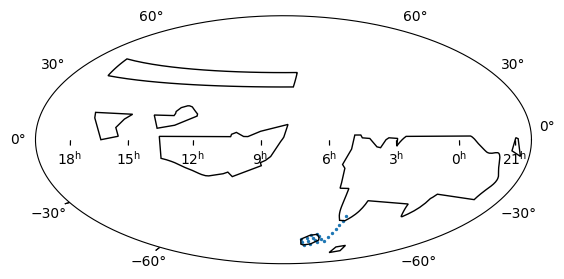

In [42]:
fig = plt.figure()
ax = fig.add_subplot(projection="astro aitoff", center="8h 0d")
ax.scatter(
    coords[keep_nodes].ra.deg,
    coords[keep_nodes].dec.deg,
    s=2,
    cmap="cool",
    transform=ax.get_transform("world"),
)
for region in [*lmlz_wide_regions, *mc_regions]:
    ax.add_patch(region.to_pixel(ax.wcs).as_artist(color="black"))

In [20]:
nmax = 20
node_costs = graph.nodes(data="cost")
digraph = nx.subgraph_view(
    graph.to_directed(), filter_edge=lambda u, v: node_costs[u] >= node_costs[v]
)
source = max(digraph.nodes, key=lambda node: node_costs[node])
keep_nodes = [
    source,
    *islice(
        (
            node
            for _, node in nx.bfs_edges(
                digraph,
                source,
                sort_neighbors=lambda nodes: sorted(
                    nodes, key=lambda node: -node_costs[node]
                ),
            )
        ),
        nmax - 1,
    ),
]

/var/folders/w5/pgrtm0vs1psb88v7z4fz0lh084mbdz/T/ipykernel_89042/2649495221.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/lpsinger/src/uvex-scheduler/.venv/lib/python3.13/site-packages/regions/shapes/polygon.py:180: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Polygon(xy=xy, **mpl_kwargs)


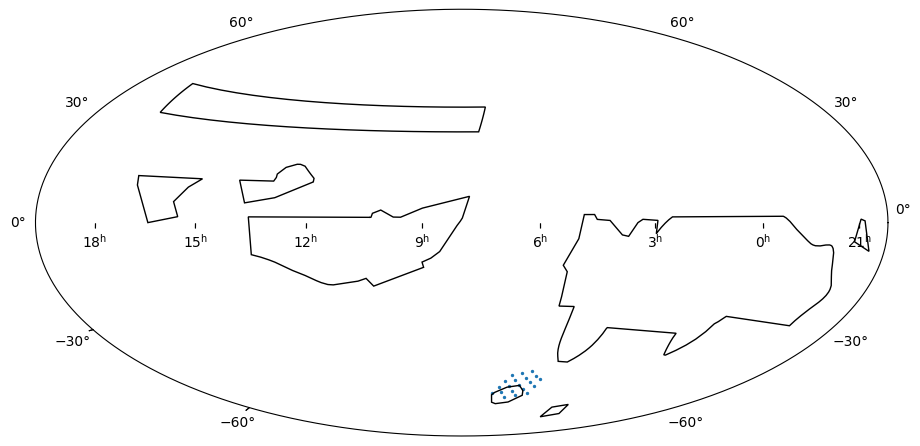

In [22]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(projection="astro aitoff", center="8h 0d")
ax.scatter(
    coords[keep_nodes].ra.deg,
    coords[keep_nodes].dec.deg,
    s=2,
    cmap="cool",
    transform=ax.get_transform("world"),
)
for region in [*lmlz_wide_regions, *mc_regions]:
    ax.add_patch(region.to_pixel(ax.wcs).as_artist(color="black"))

54 5412
54 5393
52 5374
52 5315
52 5296
52 5277
52 5258
52 5239
52 5220
52 5201
52 5182
5 5163
5 4944
5 4725
5 4206
5 4187
5 4168
5 4109
1 4050


/Users/lpsinger/src/uvex-scheduler/.venv/lib/python3.13/site-packages/regions/shapes/polygon.py:180: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Polygon(xy=xy, **mpl_kwargs)


(array([19, 20]), array([ 28, 244]))

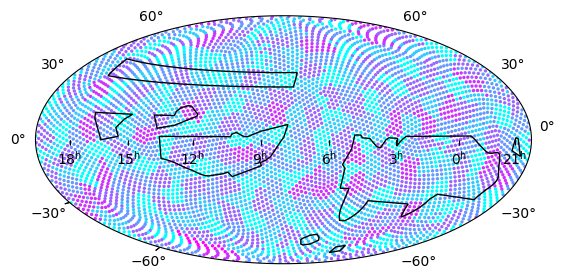

In [19]:
nmax = 20
nmin = nmax - 1
node_costs = graph.nodes(data="cost")
remaining_graph = graph.copy()
partition = np.full(graph.number_of_nodes(), -1, dtype=np.intp)

while remaining_graph.number_of_nodes() > 0:
    max_cost = max(node_costs[node] for node in remaining_graph.nodes)
    print(max_cost, remaining_graph.number_of_nodes())
    if max_cost > 1:
        nodes, *_ = nx.connected_components(
            nx.subgraph_view(
                remaining_graph, filter_node=lambda node: node_costs[node] == max_cost
            )
        )
        remainder = len(nodes) % nmax
        if remainder != 0:
            needed = nmin - remainder
            boundary = []
            while len(boundary) < needed:
                boundary.extend(nx.node_boundary(remaining_graph, [*nodes, *boundary]))
            boundary = sorted(boundary, key=lambda node: node_costs[node], reverse=True)
            nodes = [*nodes, *boundary[:needed]]
        kmin = int(np.floor(len(nodes) / nmax))
        kmax = int(np.ceil(len(nodes) / nmin))
        subgraph = remaining_graph.subgraph(nodes)
        for k in range(max(1, kmin), kmax + 1):
            for seed in [42]:
                subgraph_partition = partition_graph(
                    subgraph,
                    k,
                    seed=seed,
                    contig=True,
                    no2hop=True,
                    ncuts=200,
                    nseps=100,
                )
                _, counts = np.unique(subgraph_partition, return_counts=True)
                if np.all((counts == nmin) | (counts == nmax)):
                    break
            if np.all((counts == nmin) | (counts == nmax)):
                break
        else:
            raise RuntimeError("No suitable partition")
    else:
        subgraph = remaining_graph
        kmin = int(np.floor(remaining_graph.number_of_nodes() / nmax))
        kmax = int(np.ceil(remaining_graph.number_of_nodes() / nmin))
        nodes = graph.nodes
        for k in range(max(1, kmin), kmax + 1):
            for seed in [42]:
                subgraph_partition = partition_graph(
                    subgraph,
                    k,
                    seed=seed,
                    contig=True,
                    no2hop=True,
                    ncuts=200,
                    nseps=100,
                )
                _, counts = np.unique(subgraph_partition, return_counts=True)
                if np.all((counts >= nmin) & (counts <= nmax)):
                    break
            if np.all((counts >= nmin) & (counts <= nmax)):
                break
        else:
            raise RuntimeError("No suitable partition")
    part0 = partition.max() + 1
    for node, part in zip(subgraph.nodes, subgraph_partition + part0):
        partition[node] = part
    remaining_graph.remove_nodes_from(nodes)
# assert np.all(partition >= 0)

fig = plt.figure()
ax = fig.add_subplot(projection="astro aitoff", center="8h 0d")
ax.scatter_coord(
    coords,
    c=partition_graph_color(graph, partition)[partition],
    s=2,
    cmap="cool",
)
for region in [*lmlz_wide_regions, *mc_regions]:
    ax.add_patch(region.to_pixel(ax.wcs).as_artist(color="black"))

_, counts = np.unique(partition, return_counts=True)
np.unique(counts, return_counts=True)

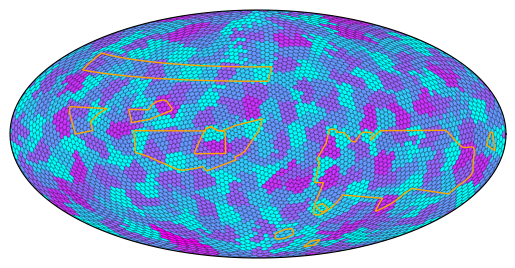

In [12]:
fig = plt.figure()
shift = 4 * u.hourangle
ax = plt.axes(
    projection="astro aitoff", center=SkyCoord(12 * u.hourangle - shift, 0 * u.deg)
)
for key in ["ra", "dec"]:
    ax.coords[key].set_ticklabel_visible(False)
    ax.coords[key].set_ticks_visible(False)
transform = ax.get_transform("world")
graph_color = partition_graph_color(graph, partition)[partition]
scalar_mappable = cm.ScalarMappable(cmap="cool")
scalar_mappable.set_array(graph_color)
for c, region in zip(graph_color, fov.footprint(inscribed_circle, coords)):
    vertices = circle_to_polygon(region, 16).vertices
    for cut_vertices in plot.cut_prime_meridian(
        np.column_stack(((vertices.ra + shift).to_value(u.rad), vertices.dec.rad))
    ):
        cut_vertices[:, 0] -= shift.to_value(u.rad)
        ax.add_patch(
            plt.Polygon(
                np.rad2deg(cut_vertices),
                ec="none",
                lw=0,
                fc=scalar_mappable.to_rgba(c),
                closed=True,
                fill=True,
                transform=transform,
            )
        )
for region in fov.footprint(inscribed_circle, coords):
    vertices = circle_to_polygon(region, 16).vertices
    for cut_vertices in plot.cut_prime_meridian(
        np.column_stack(((vertices.ra + shift).to_value(u.rad), vertices.dec.rad))
    ):
        cut_vertices[:, 0] -= shift.to_value(u.rad)
        ax.add_patch(
            plt.Polygon(
                np.rad2deg(cut_vertices),
                ec="black",
                lw=0.125,
                fc="none",
                closed=True,
                fill=False,
                transform=transform,
            )
        )

for region in [*lmlz_wide_regions, *lmlz_deep_regions, *mc_regions]:
    if isinstance(region, PointSkyRegion):
        pass  # ax.plot_coord(region.center, '+r')
    else:
        ax.add_patch(region.to_pixel(ax.wcs).as_artist(edgecolor="orange", linewidth=1))
fig.savefig("blocks.pdf")